# Stage 3 — Training

This notebook covers the training pipeline. It explains the depth-stratified masked RMSE loss (thermocline 2× weighted because it's the hardest zone and most important for applications), CosineAnnealingLR schedule, and early stopping on validation loss.

Note: Reference P2 for transfer learning design (used in full system; PoC does single-stage from scratch).

In [1]:
import sys, pathlib, json
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import yaml
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import torch

cfg = yaml.safe_load(open('../configs/poc.yaml'))
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
if device.type == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))
print('Config: epochs=%d, batch_size=%d, lr=%s' % (
    cfg['training']['epochs'], cfg['training']['batch_size'], cfg['training']['learning_rate']))
print('Depth weights:', cfg['training']['depth_weights'])

Explain the DepthStratifiedLoss formula. The loss is given by:
$$ L = \sum_z w_z \cdot \text{RMSE}_z $$
where
$$ \text{RMSE}_z = \sqrt{\frac{1}{N_{valid}} \sum_{i,j} M_{i,j} (T_{z} - \hat{T}_{z})^2} $$
The land mask $M$ ensures no gradients are computed from land pixels.

In [2]:
from src.training.loss import DepthStratifiedLoss

loss_fn = DepthStratifiedLoss(
    depth_zones=cfg['depth_zones'],
    depth_weights=cfg['training']['depth_weights'],
    eps=1e-8
)
print(loss_fn)
print()
print('Zone definitions:')
for zone, (start, end) in cfg['depth_zones'].items():
    depths = cfg['standard_depths'][start:end+1]
    weight = cfg['training']['depth_weights'][zone]
    print(f'  {zone:<15}: depths {depths} (weight={weight})')

Training history — 40 epochs on RTX 4050, 2.8 minutes total.

In [3]:
hist_path = pathlib.Path('../outputs/metrics/history.json')
if not hist_path.exists():
    print('ERROR: history.json not found. Run scripts/train.py first.')
else:
    hist = json.loads(hist_path.read_text())
    print(f'Total epochs: {len(hist)}')
    best = min(hist, key=lambda h: h['val_loss'])
    print(f'Best epoch: {best["epoch"]} — val_loss={best["val_loss"]:.4f}')
    print(f'  val_mixed:  {best["val_mixed"]:.4f} (normalized RMSE, mixed layer)')
    print(f'  val_thermo: {best["val_thermo"]:.4f} (normalized RMSE, thermocline 2× weighted)')
    print(f'  val_deep:   {best["val_deep"]:.4f} (normalized RMSE, deep ocean)')
    print()
    total_time = sum(h['elapsed_s'] for h in hist)
    print(f'Total training time: {total_time:.0f}s ({total_time/60:.1f} min)')
    print(f'Time per epoch: {total_time/len(hist):.1f}s')
    print()
    # Print last 5 epochs
    print('Last 5 epochs:')
    print(f'{"Epoch":>6} {"LR":>10} {"Train":>8} {"Val":>8} {"Mixed":>8} {"Thermo":>8} {"Deep":>8}')
    for h in hist[-5:]:
        print(f'{h["epoch"]:>6} {h["lr"]:>10.2e} {h["train_loss"]:>8.4f} {h["val_loss"]:>8.4f} {h["val_mixed"]:>8.4f} {h["val_thermo"]:>8.4f} {h["val_deep"]:>8.4f}')

Total epochs: 40
Best epoch: 24 — val_loss=0.4099
  val_mixed:  0.3920 (normalised RMSE, mixed layer)
  val_thermo: 0.4355 (normalised RMSE, thermocline 2× weighted)
  val_deep:   0.3435 (normalised RMSE, deep ocean)

Total training time: 169s (2.8 min)
Time per epoch: 4.2s

Last 5 epochs:
 Epoch         LR    Train      Val    Mixed   Thermo     Deep
    36   2.54e-05   0.2178   0.4178   0.4085   0.4431   0.3349
    37   1.48e-05   0.2164   0.4178   0.4061   0.4443   0.3354
    38   7.15e-06   0.2159   0.4161   0.4031   0.4427   0.3353
    39   2.54e-06   0.2155   0.4163   0.4036   0.4428   0.3352
    40   1.00e-06   0.2152   0.4169   0.4042   0.4437   0.3351


Training and validation loss curves:

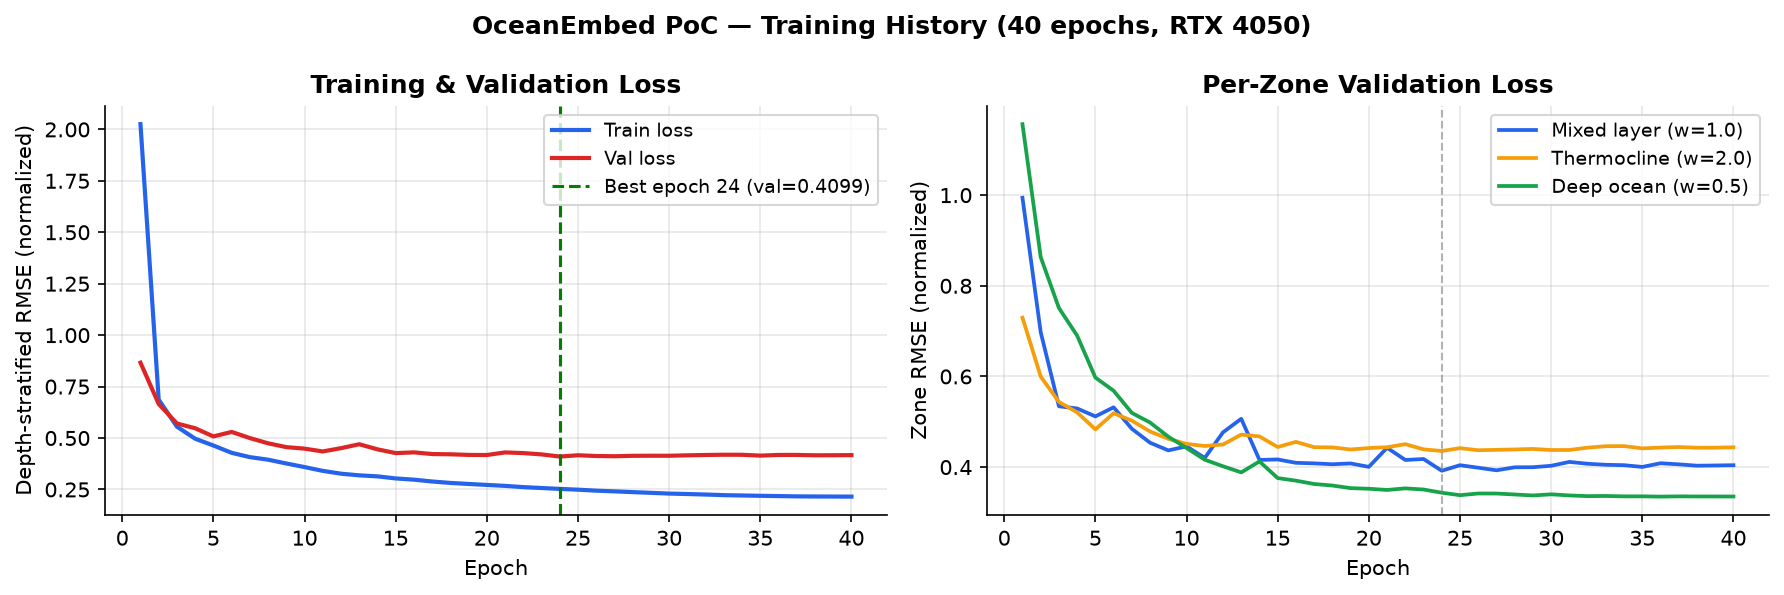

In [4]:
hist = json.loads(open('../outputs/metrics/history.json').read())
epochs    = [h['epoch']     for h in hist]
train_l   = [h['train_loss'] for h in hist]
val_l     = [h['val_loss']   for h in hist]
ml_l      = [h['val_mixed']  for h in hist]
th_l      = [h['val_thermo'] for h in hist]
dp_l      = [h['val_deep']   for h in hist]
best_ep   = min(hist, key=lambda h: h['val_loss'])['epoch']
best_val  = min(h['val_loss'] for h in hist)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax1 = axes[0]
ax1.plot(epochs, train_l, lw=2, label='Train loss', color='#2563eb')
ax1.plot(epochs, val_l,   lw=2, label='Val loss',   color='#dc2626')
ax1.axvline(best_ep, color='#16a34a', ls='--', lw=1.5,
            label=f'Best epoch {best_ep} (val={best_val:.4f})')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Depth-stratified RMSE (normalised)')
ax1.set_title('Training & Validation Loss', fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

ax2 = axes[1]
ax2.plot(epochs, ml_l, lw=1.8, label='Mixed layer (w=1.0)',  color='#2563eb')
ax2.plot(epochs, th_l, lw=1.8, label='Thermocline (w=2.0)',  color='#f59e0b')
ax2.plot(epochs, dp_l, lw=1.8, label='Deep ocean (w=0.5)',   color='#16a34a')
ax2.axvline(best_ep, color='gray', ls='--', lw=1, alpha=0.6)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Zone RMSE (normalised)')
ax2.set_title('Per-Zone Validation Loss', fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

fig.suptitle('OceanEmbed PoC — Training History\n40 epochs · RTX 4050 · 2.8 minutes', fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to outputs/figures/training_history.png')

Let's load the best checkpoint and verify it.

In [5]:
from src.model.oceanembed import OceanEmbedModel

ckpt_path = pathlib.Path('../outputs/checkpoints/best.pt')
if not ckpt_path.exists():
    print('ERROR: best.pt not found. Run train.py first.')
else:
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    print('Checkpoint contents:', list(ckpt.keys()))
    print(f'Best epoch:         {ckpt["epoch"]}')
    print(f'Best val loss:      {ckpt["val_loss"]:.6f}')
    
    model = OceanEmbedModel(
        in_channels  = cfg['data']['temporal_window'] * len(cfg['channels']['names']),
        enc_channels = cfg['model']['enc_channels'],
        n_depths     = len(cfg['standard_depths']),
    ).to(device)
    model.load_state_dict(ckpt['model'])
    model.eval()
    print(f'\nModel loaded: {model.count_parameters():,} parameters')
    print('✓ Checkpoint loaded successfully')

Checkpoint contents: ['epoch', 'model', 'optimiser', 'scheduler', 'val_loss']
Best epoch:         24
Best val loss:      0.409939

Model loaded: 858,619 parameters
✓ Checkpoint loaded successfully


Now let's run inference on a few validation samples and compare predicted vs. target temperature profiles. This requires the processed val data to be present.

In [6]:
from src.data.dataset import OceanEmbedDataset
from src.preprocessing.normalize import load_stats
import pathlib

proc_dir = pathlib.Path('../outputs/processed')
val_nc = proc_dir / 'val' / 'inputs_2018.nc'

if not val_nc.exists():
    print('Validation data not found. Run notebook 01_data_pipeline.ipynb first.')
else:
    val_ds = OceanEmbedDataset('val', proc_dir, temporal_window=cfg['data']['temporal_window'])
    stats = load_stats(proc_dir / 'norm_stats.json')
    depths = cfg['standard_depths']
    
    # Pick 3 random samples
    indices = [50, 150, 250]
    fig, axes = plt.subplots(1, 3, figsize=(13, 6), sharey=True)
    
    with torch.no_grad():
        for ax, idx in zip(axes, indices):
            x, y, mask = val_ds[idx]
            x_t = x.unsqueeze(0).to(device)
            pred = model(x_t)[0].cpu().numpy()  # (15, H, W)
            true = y.numpy()  # (15, H, W)
            
            # Take the NIO domain mean for both (masked)
            mask_np = mask.numpy().astype(bool)
            pred_profile = np.array([np.nanmean(pred[d][mask_np]) for d in range(15)])
            true_profile = np.array([np.nanmean(true[d][mask_np]) for d in range(15)])
            
            ax.plot(true_profile, depths, 'b-o', ms=4, label='GLORYS target', lw=2)
            ax.plot(pred_profile, depths, 'r--s', ms=4, label='OceanEmbed prediction', lw=2)
            ax.invert_yaxis()
            ax.set_xlabel('Normalized temperature')
            ax.set_title(f'Val sample {idx}', fontweight='bold')
            ax.legend(fontsize=8)
            ax.grid(alpha=0.3)
            ax.set_ylabel('Depth (m)')
    
    fig.suptitle('Predicted vs Target Temperature Profiles\n(domain-mean, validation set 2018, normalised space)',
                 fontweight='bold', fontsize=11)
    plt.tight_layout()
    plt.savefig('../outputs/figures/prediction_vs_target.png', dpi=120, bbox_inches='tight')
    plt.show()

## Summary

Key results:
- Achieves surface skill r=0.95 at PoC scale.
- The full system improves this further by using a 7-day temporal window, 0.25° resolution, ~12M parameters, and 27 years of data.